# Data5441 - Networks and High-dimensional Inference 
Semester 2, 2026


# Tutorial Week 3

This notebook contains code and guided questions. You are encouraged to perform your calculations, explorations, and estimates here and use the results to answer the following exercises.


In this tutorial, we compare empirical networks with fitted random graphs, study dense and sparse Erdős-Rényi random graphs including the sparse Poisson regime, and investigate path-based measures and the emergence of the largest component.


In [40]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import pandas as pd

In [41]:
def compute_graph_properties(G):
    degrees = np.array([d for _, d in G.degree()], dtype=float)
    H = G if nx.is_connected(G) else G.subgraph(max(nx.connected_components(G), key=len))

    avg_deg = np.mean(degrees)
    deg_std = np.std(degrees)
    deg_variability = deg_std / avg_deg if avg_deg > 0 else 0.0
    C_net = nx.transitivity(G)
    avg_shortest_path = nx.average_shortest_path_length(H)
    diameter =nx.diameter(H)
    return avg_deg, deg_variability, C_net, avg_shortest_path, diameter

# 1. Introduction


## 1.1. Motivation

We compare an empirical network $G$ (a simple graph) with random-graph models fitted to it.

- When choosing $G$, you are encouraged to consider a network of your choice (simple graph with $N>30$), such as the one you used in Week 1 but you can also choose a network discussed in class.

- When computing numerical estimates, estimate their uncertainty, for example by generating multiple realizations, to ensure that the results have the required precision.
   


## 1.2. Notation

The following measures characterize local and global properties of a network:

- $z_i$: degree of node $i$, where $i=1,2,\ldots,N$.
- $C_i$: local clustering coefficient of node $i$.
- $C_{net}=3N_{\triangle}/N_{\mathrm{triples}}$: network transitivity, where $N_{\triangle}$ is the number of triangles and $N_{\mathrm{triples}}$ is the number of connected triples. In general, $C_{net}\neq\langle C\rangle$.
- $d_{ij}$: geodesic distance between nodes $i$ and $j$.
- $\langle d_i\rangle=\frac{1}{N-1}\sum_{j\ne i}d_{ij}$: average distance from node $i$ to all other nodes.
- $\langle\langle d\rangle\rangle=\frac{1}{N(N-1)}\sum_{i\ne j}d_{ij}$: average shortest-path length.
- $d_{diam}=\max_{i,j}d_{ij}$: network diameter.

Distance-based measures require a connected graph or a specified connected component. Unless otherwise stated, $\langle f\rangle=\frac{1}{N}\sum_{i=1}^N f_i$ denotes an average over all nodes.


# 2. Comparing random graphs and real networks

Our interest here is to investigate whether observations in a real network are compatible with the expectations based on a random graph model. An Erdős-Rényi (ER) random graph $G(N,q)$ has $N$ nodes, with each possible edge included independently with probability $q$.

Consider the 5 measurements

- $\langle z \rangle$ (average degree)
- $\sigma_z/\langle z \rangle$ (degree variability)
- $C_{net}$ (clustering coefficient)
- $\langle \langle d \rangle \rangle$ (average shortest path)
- $d_{diam}$ (diameter)

and the two networks:

- $G_k$: the Karate Club network (as below)
- G2: a simple graph of your choice (e.g., the ones you considered in previous weeks)

For each measurement and network, determine whether it is **compatible** with an ER random graph fitted to it, i.e., an ER random graph with the same number of nodes $N$ and links $L$ as the network.

 We use a simulation-based two-standard-deviation rule as a heuristic **compatibility** criterion. For a measurement $x$, define

$$\mu_x=\langle x_{rg}\rangle, \qquad \sigma_x=\sqrt{\langle x_{rg}^2\rangle-\mu_x^2}.$$

We call the observed value compatible when

$$|x_G-\mu_x|\leq 2\sigma_x,$$

or equivalently when $x_G\in[\mu_x-2\sigma_x,\,\mu_x+2\sigma_x]$.


In [42]:
Gk=nx.karate_club_graph()

N_k = Gk.number_of_nodes()
L_k = Gk.number_of_edges()

## Exercise 2.1. Choosing an empirical network



Which network $G$ are you using? Report the number of nodes $N$ and edges $L$ in $G$.

Note: Measures related to the path between nodes (e.g., $\langle \langle d \rangle \rangle$ and $d_{diam}$) are only meaningful in the same connected component of the network. For these cases, consider the largest component of your networks.


Number of nodes: 453
Number of edges: 2040


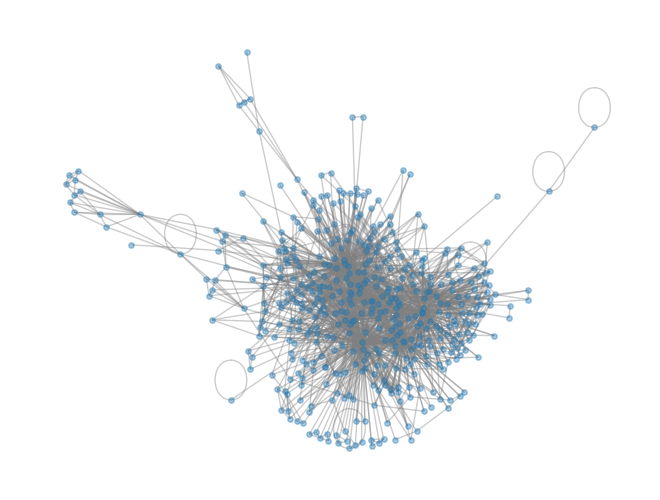

In [43]:
# C-Elegens network
ce_df = pd.read_csv("data/celegans_edgelist.txt", sep=r"\s+", header=None, names=["node1", "node2", "value"])
Gce = nx.from_pandas_edgelist(ce_df, source="node1", target="node2", edge_attr="value")

N_ce = Gce.number_of_nodes()
L_ce = Gce.number_of_edges()

print("Number of nodes:", N_ce)
print("Number of edges:", L_ce)

pos = nx.spring_layout(Gce, seed=42, method="force")
nx.draw(Gce, pos, with_labels=False, node_size=15, edge_color='gray', alpha=0.4)

## Exercise 2.2. ER/Poisson random graph comparison

Let $G_p$ be the ER/Poisson random graph $G(N, q)$ fitted to $G$ (i.e., both $G$ and $G_p$ have the same number of nodes $N$ and links $L$ as $G$). Estimate the value of all five quantities of interest listed above in $G_p$.



In [44]:
def compute_graph_measures(G):
    degrees = np.array([d for _, d in G.degree()], dtype=float)
    avg_deg = np.mean(degrees)
    degree_variability = (np.std(degrees) / avg_deg if avg_deg > 0 else 0.0)
    transitivity = nx.transitivity(G)

    # Use largest connected component for distance-based measures
    if G.number_of_nodes() == 0:
        avg_shortest_path = np.nan
        diameter = np.nan
    else:
        H = (G if nx.is_connected(G) else G.subgraph(max(nx.connected_components(G), key=len)).copy())
        avg_shortest_path = nx.average_shortest_path_length(H)
        diameter = nx.diameter(H)

    return {
        "average_degree": avg_deg,
        "degree_variability": degree_variability,
        "transitivity": transitivity,
        "average_shortest_path": avg_shortest_path,
        "diameter": diameter,
    }



def compare_G_with_er(G, num_random=1000, num_stds=2, seed=42):

    N = G.number_of_nodes()
    L = G.number_of_edges()

    q = (2 * L / (N * (N - 1)) if N > 1 else 0.0)

    observed = compute_graph_measures(G)
    rng = np.random.default_rng(seed)
    simulations = []

    for _ in range(num_random):
        graph_seed = int(rng.integers(0, np.iinfo(np.int32).max))

        G_er = nx.erdos_renyi_graph(N, q, seed=graph_seed)
        simulations.append(compute_graph_measures(G_er))

    simulations = pd.DataFrame(simulations)

    rows = []
    for measure, G_value in observed.items():
        values = simulations[measure].dropna()
        ER_mean = values.mean()
        ER_std = values.std(ddof=1)

        difference = abs(G_value - ER_mean)
        tolerance = num_stds * ER_std

        if ER_std > 0:
            num_stds_away = difference / ER_std
        elif difference == 0:
            num_stds_away = 0.0
        else:
            num_stds_away = np.inf

        compatible = difference <= tolerance

        rows.append({
            "measure": measure,
            "G_value": G_value,
            "ER_mean": ER_mean,
            "ER_std": ER_std,
            "lower_bound": ER_mean - num_stds * ER_std,
            "upper_bound": ER_mean + num_stds * ER_std,
            "difference": difference,
            "num_stds_away": num_stds_away,
            "compatible": compatible,
        })

    return pd.DataFrame(rows)

Karate Club vs its Erdos-Renyi

In [45]:
karate_comparison = compare_G_with_er(Gk, num_random=100, num_stds=2, seed=42)
karate_comparison

,measure,G_value,ER_mean,ER_std,lower_bound,upper_bound,difference,num_stds_away,compatible
0,average_degree,4.588235,4.583529,0.404846,3.773837,5.393222,0.004706,0.011624,True
1,degree_variability,0.832643,0.420266,0.044449,0.331368,0.509164,0.412377,9.277527,False
2,transitivity,0.255682,0.131161,0.035198,0.060765,0.201557,0.124521,3.537712,False
3,average_shortest_path,2.408200,2.413743,0.126862,2.160018,2.667468,0.005544,0.043698,True
4,diameter,5.000000,4.820000,0.641652,3.536696,6.103304,0.180000,0.280526,True


In [46]:
ce_comparison = compare_G_with_er(Gce, num_random=100, num_stds=2, seed=42)
ce_comparison.to_clipboard()

In [47]:
Gce.number_of_edges(), Gce.number_of_nodes()

(2040, 453)

# 3. Erdős-Rényi Random Graphs


We consider Erdős-Rényi random graphs $G(N, q)$ with

$N:$ nodes

$q:$ probability with which each possible edge is included independently

The goal of this tutorial is to explore the properties of Erdős-Rényi random graphs for different parameters, focusing on $N\rightarrow \infty$.


## Case 1: Fixed $q$


Here we fix $q=0.1$ and $N=50$. At finite $N$, the degree distribution is binomial. 

In [48]:
N=50
q=0.1
Ger=nx.erdos_renyi_graph(N,q,seed=13)

Quantities of interest for one realization of the Poisson Random Graph


We can compute the clustering coefficient:


In [49]:
nx.transitivity(Ger)

0.07939508506616257

Distances (average shortest path $\langle \langle d \rangle \rangle$) and diameter ($d_{diam}$):


In [50]:
nx.average_shortest_path_length(Ger)

2.679183673469388

In [51]:
nx.diameter(Ger)

6

Degrees: average $\langle z \rangle$ and relative fluctuations $\sigma_z /\langle z \rangle$


In [52]:
degs=[Ger.degree()[node] for node in list(Ger.nodes())]

Average degree


In [53]:
np.average(degs)

np.float64(4.68)

Fluctuations of degree


In [54]:
np.std(degs)/np.average(degs)

np.float64(0.42400399161752006)

## Exercise 3.1. Dense random graphs

Compute

- $\langle z \rangle$ (average degree)
- $\sigma_z/\langle z \rangle$ (degree variability)
- $C_{net}$ (clustering coefficient)
- $\langle \langle d \rangle \rangle$ (average shortest path)
- $d_{diam}$ (diameter)

for $q=0.1$ and increasing $N$. Discuss whether each quantity grows, decays, or seems to converge to a limiting value as $N \rightarrow \infty$.


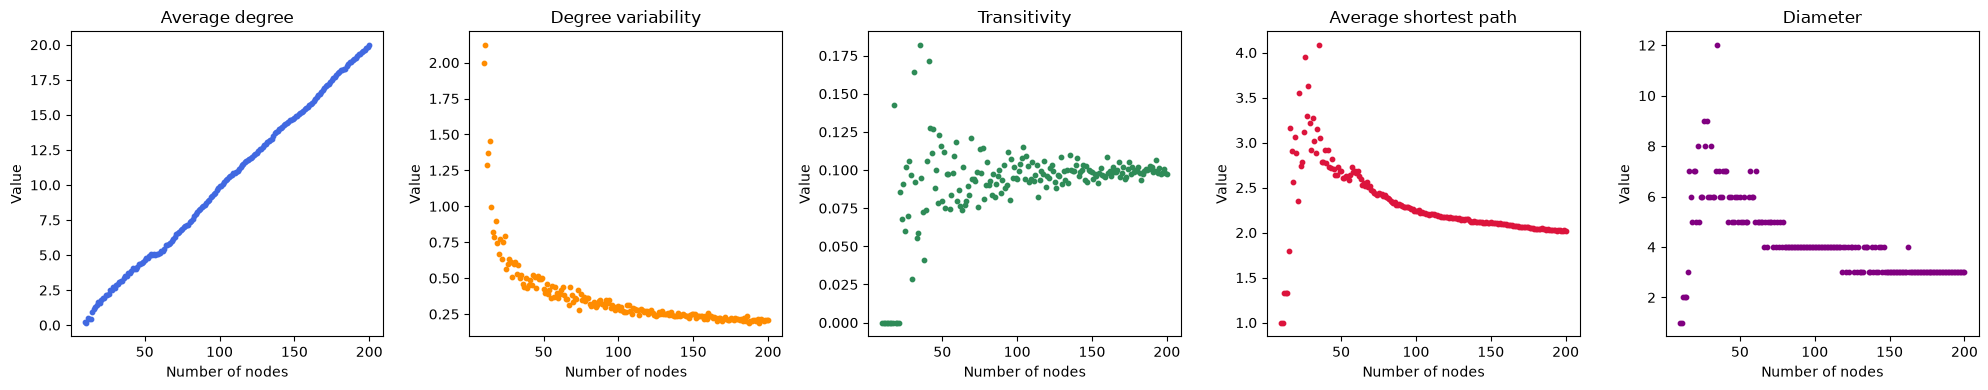

In [55]:
N_max=200
N_list = np.arange(10, N_max+1, 1)

q = 0.1

properties_data_case_1 = pd.DataFrame(columns=['N', 'avg_deg', 'deg_variability', 'C_net', 'avg_shortest_path', 'diameter'])

for N in N_list:
    Ger = nx.erdos_renyi_graph(N, q, seed=13)
    avg_deg, deg_variability, C_net, avg_shortest_path, diameter = compute_graph_properties(Ger)
    properties_data_case_1.loc[len(properties_data_case_1)] = [N, avg_deg, deg_variability, C_net, avg_shortest_path, diameter]


fig, axes = plt.subplots(1, 5, figsize=(20, 4))

metrics = ['avg_deg', 'deg_variability', 'C_net', 'avg_shortest_path', 'diameter']
titles = ['Average degree', 'Degree variability', 'Transitivity', 'Average shortest path', 'Diameter']
colours = ['royalblue', 'darkorange', 'seagreen', 'crimson', 'purple']

for ax, metric, title, colour in zip(axes, metrics, titles, colours):
    ax.scatter(properties_data_case_1['N'], properties_data_case_1[metric], color=colour, s=10)
    ax.set_title(title)
    ax.set_xlabel('Number of nodes')
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

In [56]:
N = 100
C_net = np.zeros(1000)
q = 0.1

for i in range(len(C_net)):
    Ger = nx.erdos_renyi_graph(N, q)
    C_net[i] = nx.transitivity(Ger)

print(f"Average transitivity: {np.mean(C_net)}, Standard deviation: {np.std(C_net)}")

Average transitivity: 0.09930495265276641, Standard deviation: 0.008116395218569904


## Case 2: fixed average degree (number of edges)


Here we fix the expected average degree $\langle z \rangle$ and investigate how properties vary with $N$.

$\langle z \rangle = q(N-1)$

We are interested in the limit $N \rightarrow \infty$ and $q\rightarrow 0$ such that $\langle z \rangle$ is constant, achieved by choosing $q=\frac{\langle z \rangle}{N-1}$. The name Poisson random graph refers to this sparse limit, where the degree distribution converges to a Poisson distribution.


*Example*: A network with expected average degree $3$ is obtained as:


In [57]:
avgz=3
N=50
q=avgz/(N-1)
Ger=nx.erdos_renyi_graph(N,q,seed=13)

## Exercise 3.2. Sparse random graphs


Repeat the computations done for Case 1 (dense networks) for Case 2 (sparse networks). Discuss whether each quantity grows, decays, or seems to converge to a limiting value as $N$ increases.


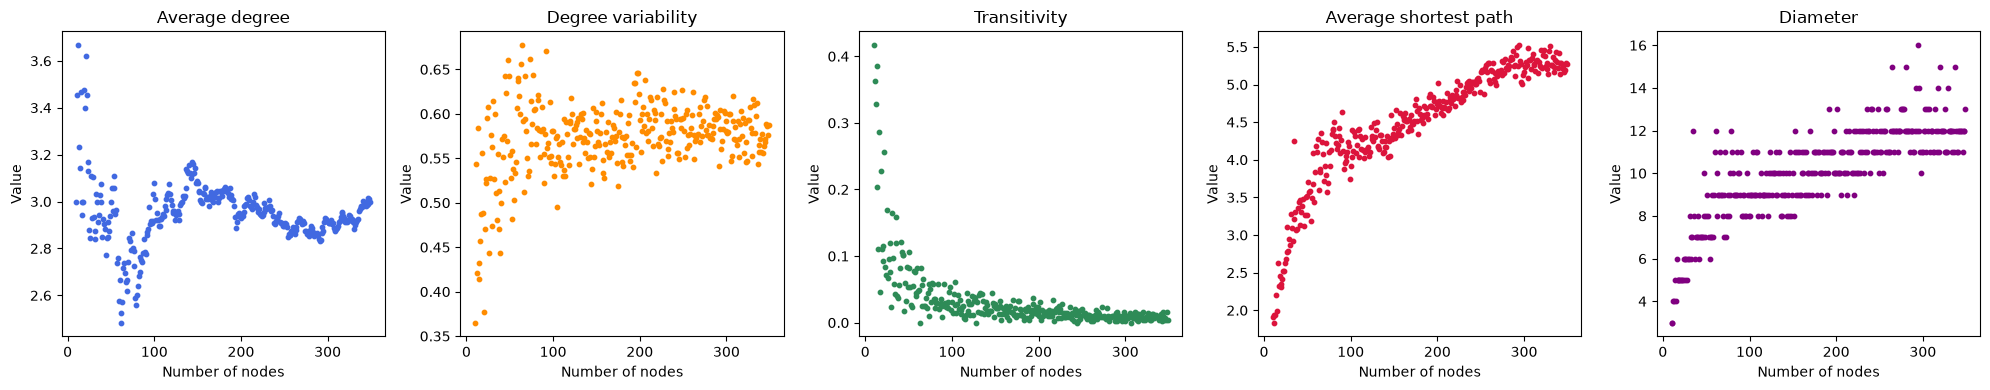

In [58]:
N_max = 350
N_list = np.arange(10, N_max, 1)
avgz=3

properties_data_case_2 = pd.DataFrame(columns=['N', 'avg_deg', 'deg_variability', 'C_net', 'avg_shortest_path', 'diameter'])

for N in N_list:
    q = avgz / (N - 1)
    Ger = nx.erdos_renyi_graph(N, q, seed=13)
    avg_deg, deg_variability, C_net, avg_shortest_path, diameter = compute_graph_properties(Ger)
    properties_data_case_2.loc[len(properties_data_case_2)] = [N, avg_deg, deg_variability, C_net, avg_shortest_path, diameter]


fig, axes = plt.subplots(1, 5, figsize=(20, 4))

metrics = ['avg_deg', 'deg_variability', 'C_net', 'avg_shortest_path', 'diameter']
titles = ['Average degree', 'Degree variability', 'Transitivity', 'Average shortest path', 'Diameter']
colours = ['royalblue', 'darkorange', 'seagreen', 'crimson', 'purple']

for ax, metric, title, colour in zip(axes, metrics, titles, colours):
    ax.scatter(properties_data_case_2['N'], properties_data_case_2[metric], color=colour, s=10)
    ax.set_title(title)
    ax.set_xlabel('Number of nodes')
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

In [59]:
N = 100
C_net = np.zeros(1000)
avgz=3

for i in range(len(C_net)):
    q = avgz / (N - 1)
    Ger = nx.erdos_renyi_graph(N, q)
    C_net[i] = nx.transitivity(Ger)

print(f"Average transitivity: {np.mean(C_net)}, Standard deviation: {np.std(C_net)}")

Average transitivity: 0.029850004148373268, Standard deviation: 0.01399884501162926


# 4. Computations in the largest component

## 4.1. Distances within the largest component

For a disconnected graph, average shortest path and diameter are computed here on its largest connected component.


In [60]:
Ggiant=max(nx.connected_components(Ger),key=len) # This command restricts the nodes to the largest component
Gcc=Ger.subgraph(Ggiant)

Diameter and average shortest path depend on the component considered.


In [61]:
nx.diameter(Gcc)

10

In [62]:
nx.average_shortest_path_length(Gcc)

4.223516237402015

In [63]:
components=list(nx.connected.connected_components(Ger))
lengthcomponents=[len(c) for c in components]
lengthcomponents.sort(reverse=True)
fractionK=lengthcomponents[0]/sum(lengthcomponents)

In [64]:
lengthcomponents

[95, 1, 1, 1, 1, 1]

## 4.2. Size of the largest component

We denote by $K_1$ the fraction of all nodes contained in the largest connected component.


In [65]:
avgz=4
N=100
q=avgz/(N-1)

Ger=nx.erdos_renyi_graph(N,q,seed=17) # Generate the network

components=list(nx.connected.connected_components(Ger))
lengthcomponents=[len(c) for c in components]
lengthcomponents.sort(reverse=True) #Sorted length of components

fractionK=lengthcomponents[0]/sum(lengthcomponents) #Fraction of all nodes that are in the largest component

print("Fraction of nodes in the largest component is: "+str(fractionK))

Fraction of nodes in the largest component is: 0.97


In [66]:
avgz=1
N=100
q=avgz/(N-1)

Ger=nx.erdos_renyi_graph(N,q,seed=18) # Generate the network

components=list(nx.connected.connected_components(Ger))
lengthcomponents=[len(c) for c in components]
lengthcomponents.sort(reverse=True) #Sorted length of components

fractionK=lengthcomponents[0]/sum(lengthcomponents) #Fraction of all nodes that are in the largest component

print("Fraction of nodes in the largest component is: "+str(fractionK))

Fraction of nodes in the largest component is: 0.24


In [67]:
Nvec=[10,20,100,200,1000,2000]#,10000,20000]
avgz=1
print("\n <z>=",avgz,"\n N, fraction in largest component")
for i,N in enumerate(Nvec):        
    q=avgz/(N-1)
    Ger=nx.erdos_renyi_graph(N,q,seed=30+i)
    components=list(nx.connected.connected_components(Ger))
    lengthcomponents=[len(c) for c in components]
    lengthcomponents.sort(reverse=True)
    fractionK=lengthcomponents[0]/sum(lengthcomponents)
    print(N,fractionK)


 <z>= 1 
 N, fraction in largest component
10 0.4
20 0.35
100 0.25
200 0.08
1000 0.114
2000 0.119


## Exercise 4.1. Largest-component transition

Investigate how the size of the largest component varies with $\langle z \rangle$ and $N\rightarrow \infty$.

- Do you observe the transition discussed in class?
- What is the effect of $N$?


In [79]:
N_list = [25, 50, 100, 200, 500, 1000]
avg_deg_list = np.linspace(0.1, 4, 40)

num_realisations = 50

records = []

for N in N_list:
    for avg_deg in avg_deg_list:
        q = avg_deg / (N - 1)
        K1_sum = 0.0

        for r in range(num_realisations):
            G = nx.fast_gnp_random_graph(N,q, seed=100000 * N + 1000 * int(avg_deg * 100) + r)
            largest_component_size = max(len(c) for c in nx.connected_components(G))
            K1_sum += largest_component_size / N

        records.append({"N": N, "avg_deg": avg_deg, "K1": K1_sum / num_realisations})

df = pd.DataFrame(records)

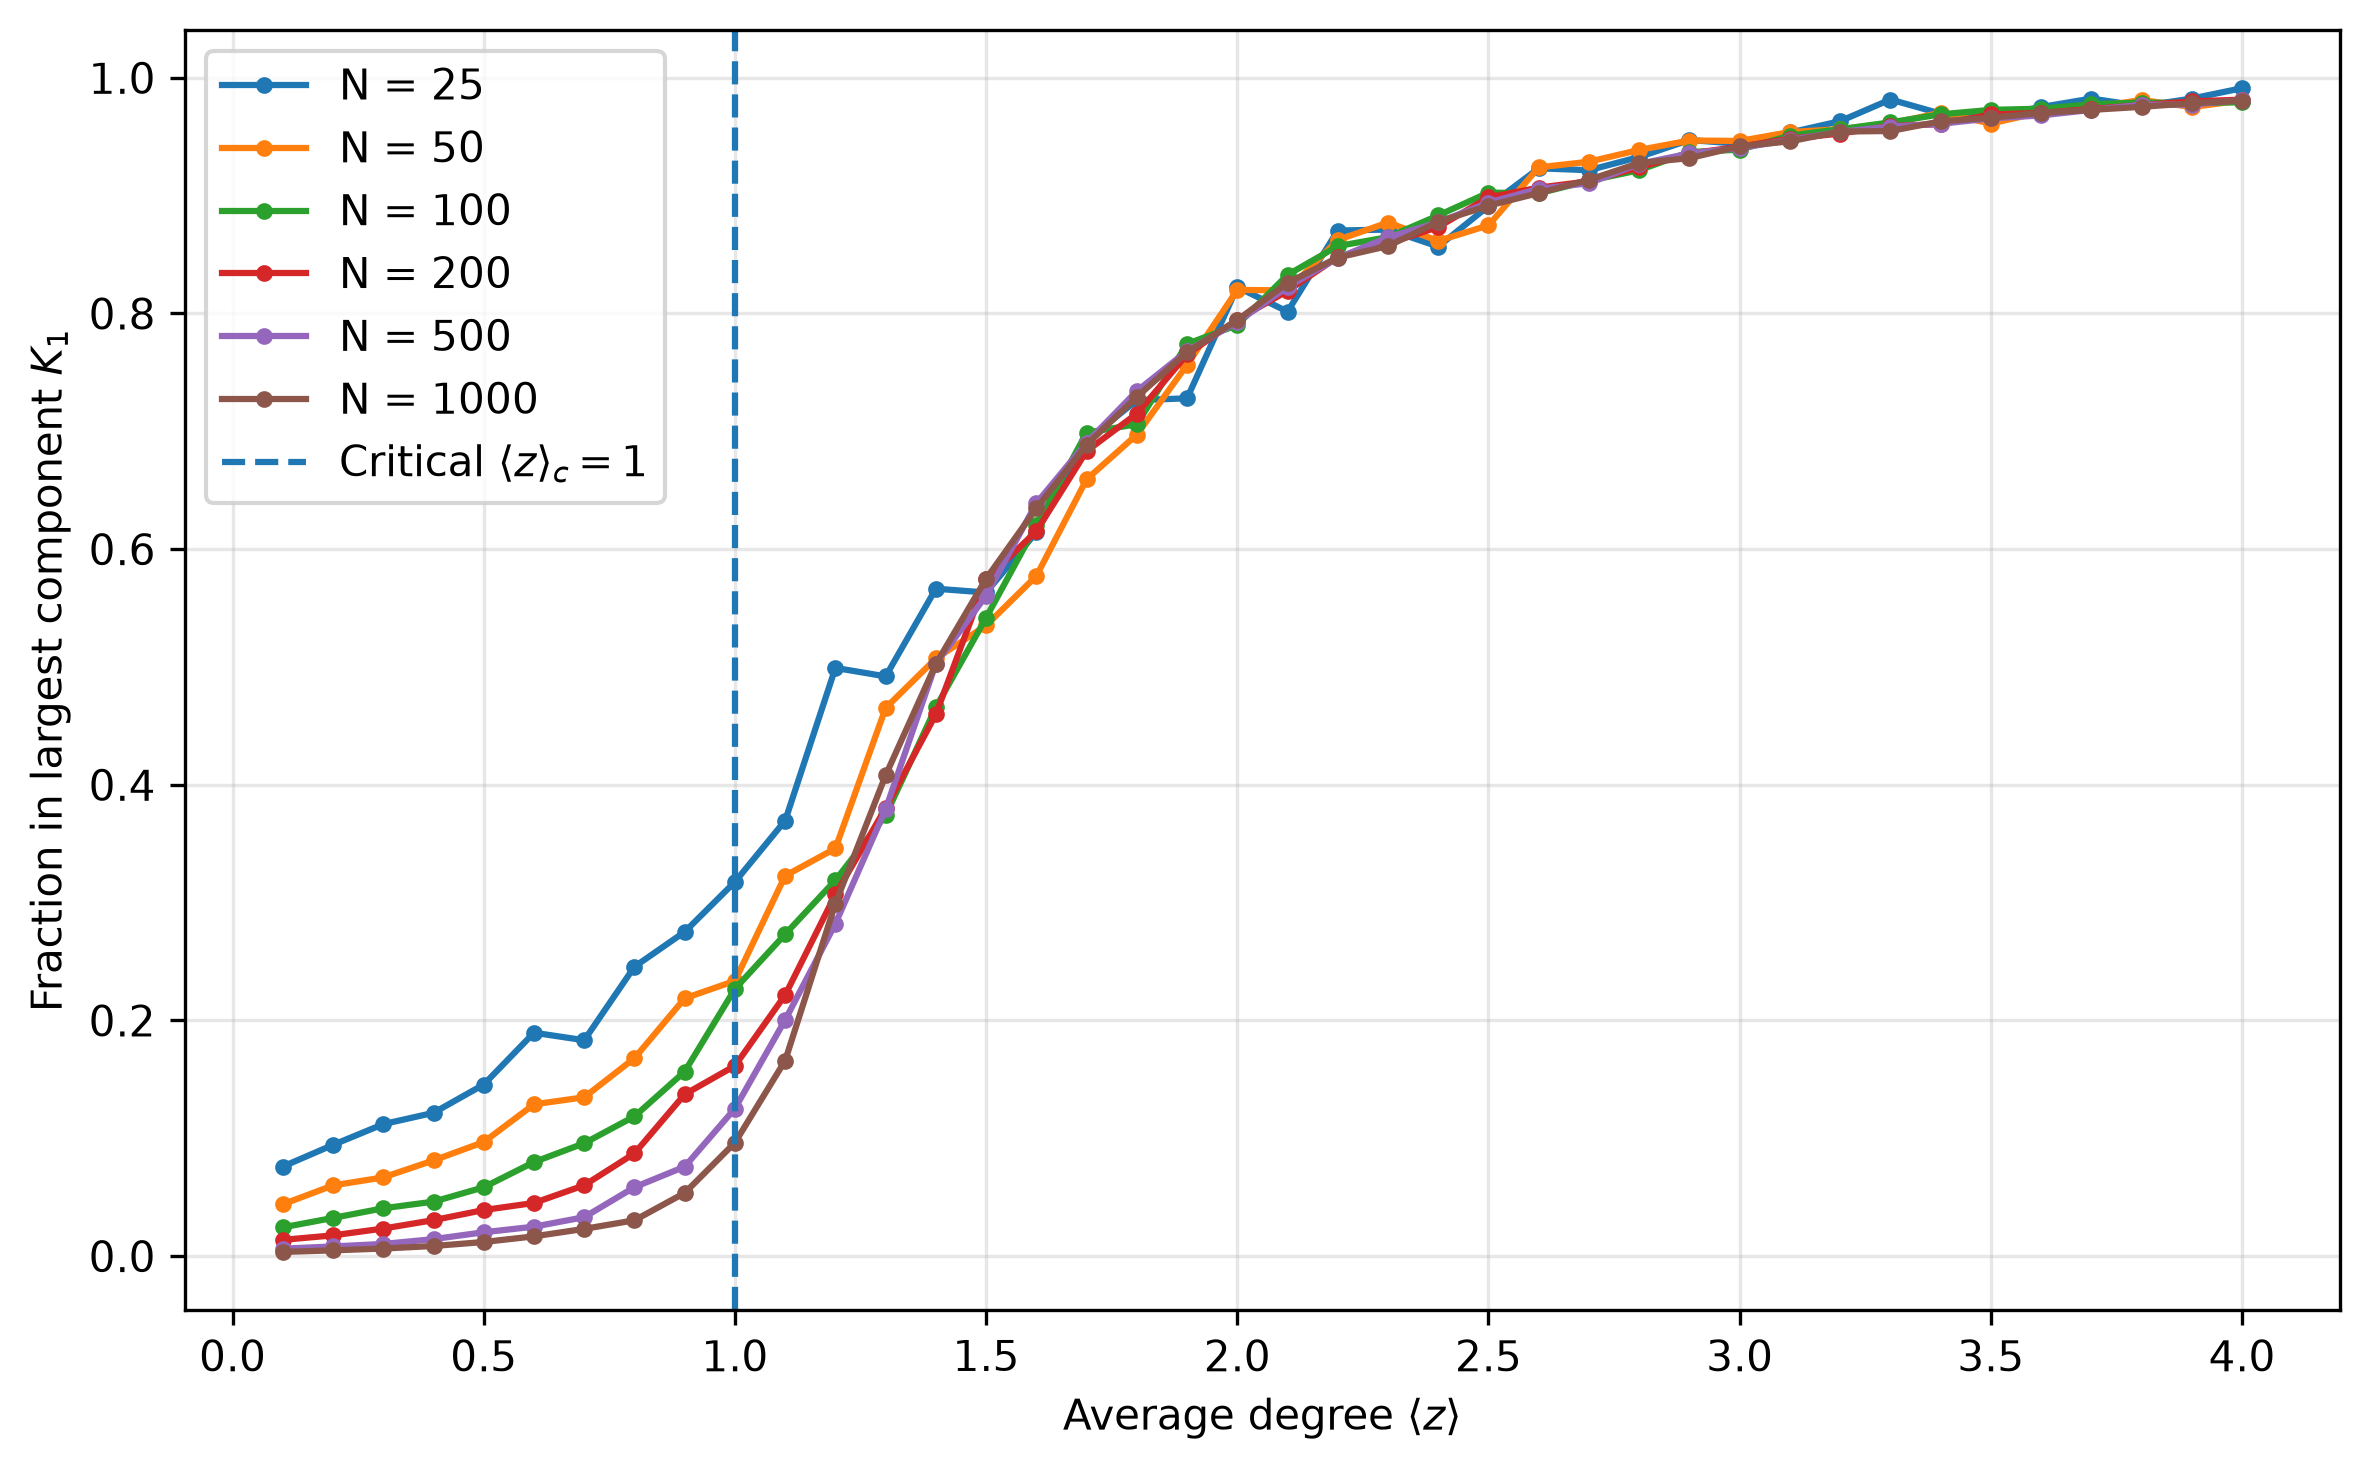

In [80]:
plt.figure(figsize=(8, 5), dpi=300)

for N in N_list:
    subset = df[df["N"] == N]

    plt.plot(subset["avg_deg"], subset["K1"], marker="o", markersize=3, label=f"N = {N}")

plt.axvline(x=1, linestyle="--", label=r"Critical $\langle z\rangle_c = 1$")

plt.xlabel(r"Average degree $\langle z\rangle$")
plt.ylabel(r"Fraction in largest component $K_1$")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()